# 五特征对比：build-3 自定义函数 vs batch compute_all_features

使用同一 TDMS 数据文件、相同滑窗与预处理方式，分别用两种方法计算五个特征并对比差异。

- **方法A**：来自 `2026-05-19-realdata_feature_dataset_build-3.ipynb` 的自定义函数（`_spectral_centroid_mean` 等）
- **方法B**：来自 `2026-05-06-batch_feature_extract_12folders_gpu.ipynb` 的 `compute_all_features` 完整函数


## 1. 模块导入与配置


In [1]:
from __future__ import annotations
from dataclasses import replace
from pathlib import Path
import sys

import numpy as np
import pandas as pd

workspace = Path.cwd()
if not (workspace / "src").exists():
    workspace = workspace.parent
if str(workspace / "src") not in sys.path:
    sys.path.insert(0, str(workspace / "src"))

from fea_cpt_gpu.base import FeatureRecord
from fea_cpt_gpu.params import DEFAULT_FEATURE_PARAMS
from fea_cpt_gpu.signal_ops import build_context, butter_filter
from fea_cpt_gpu.features import compute_all_features

try:
    from nptdms import TdmsFile
except ImportError:
    TdmsFile = None

print("模块加载完成")
print(f"workspace = {workspace}")
print(f"nptdms = {'available' if TdmsFile is not None else 'missing'}")


模块加载完成
workspace = e:\codes\ZZ-BK
nptdms = available


d:\anaconda3\envs\py312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 参数与特征配置


In [2]:
# =========================
# 配置
# =========================
DATA_FILE = Path(r"G:\20260323_ZZ_pccp\FIP\24-900-1800\test2\0002341-500K-20260324T201052.395.tdms")

WINDOW_DURATION_S = 0.02       # 20 ms 每窗口
WINDOW_OVERLAP = 0.50         # 50% 重叠

BANDS = {
    "b_1k_100k": (1_000.0, 100_000.0),
    "b_1k_10k":  (1_000.0, 10_000.0),
}

PREPROC_BAND = (1_000.0, 95_000.0)

SELECTED_FEATURES = [
    "b_1k_10k__SC_mean",
    "b_1k_10k__C_f",
    "b_1k_100k__epsilon_2x",
    "b_1k_100k__SC_res_mean",
    "b_1k_100k__I_burst",
]

print(f"数据文件: {DATA_FILE}")
print(f"窗口: {WINDOW_DURATION_S}s, 重叠: {WINDOW_OVERLAP}")
print(f"目标特征: {SELECTED_FEATURES}")


数据文件: G:\20260323_ZZ_pccp\FIP\24-900-1800\test2\0002341-500K-20260324T201052.395.tdms
窗口: 0.02s, 重叠: 0.5
目标特征: ['b_1k_10k__SC_mean', 'b_1k_10k__C_f', 'b_1k_100k__epsilon_2x', 'b_1k_100k__SC_res_mean', 'b_1k_100k__I_burst']


## 3. TDMS 加载辅助函数


In [3]:
# =========================
# TDMS 加载辅助函数（与 build-3 完全一致）
# =========================

def _scalar_text(value):
    if value is None:
        return ""
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="ignore").strip()
    if isinstance(value, np.generic):
        value = value.item()
    if hasattr(value, "tolist") and not isinstance(value, str):
        try:
            value = value.tolist()
        except Exception:
            pass
    if isinstance(value, (list, tuple)) and len(value) == 1:
        return _scalar_text(value[0])
    return str(value).strip()


def _first_property(props, names):
    normalized = {str(k).lower(): v for k, v in props.items()}
    for name in names:
        if name.lower() in normalized:
            return normalized[name.lower()]
    return None


def _coerce_float(value):
    if value is None:
        return None
    try:
        arr = np.asarray(value)
        if arr.shape == ():
            return float(arr.item())
        if arr.size == 1:
            return float(arr.reshape(()).item())
    except Exception:
        pass
    try:
        return float(value)
    except Exception:
        return None


def _select_tdms_channel(tdms_file):
    pref = {"phase_data", "signal", "data", "values", "channel0", "ch0"}
    for g in tdms_file.groups():
        for c in g.channels():
            if str(c.name).lower() in pref:
                return g, c
    best = None
    best_len = -1
    for g in tdms_file.groups():
        for c in g.channels():
            try:
                arr = np.asarray(c[:])
                if arr.size == 0:
                    continue
                if not np.issubdtype(arr.dtype, np.number):
                    arr = arr.astype(float)
            except Exception:
                continue
            if arr.size > best_len:
                best_len = arr.size
                best = (g, c)
    if best is None:
        raise ValueError("No usable numeric channel found in TDMS")
    return best


print("TDMS 辅助函数定义完成")


TDMS 辅助函数定义完成


## 4. 加载 TDMS 数据并预处理


In [9]:
# =========================
# 加载 TDMS 数据并预处理
# =========================

td = TdmsFile.read(DATA_FILE)
g, c = _select_tdms_channel(td)

raw_signal = np.asarray(c[:], dtype=float)

props = {}
props.update(getattr(td, "properties", {}) or {})
props.update(getattr(g, "properties", {}) or {})
props.update(getattr(c, "properties", {}) or {})

sample_rate = _coerce_float(_first_property(props, ("sample_rate", "sample_rate_hz", "sampling_rate", "sampling_rate_hz")))
if sample_rate is None:
    wf_inc = _coerce_float(_first_property(props, ("wf_increment",)))
    if wf_inc and wf_inc > 0:
        sample_rate = 1.0 / wf_inc
sample_rate = sample_rate or 500_000.0  

print(f"采样率: {sample_rate} Hz")
print(f"原始信号长度: {len(raw_signal)} 样本")
print(f"原始信号时长: {len(raw_signal) / sample_rate:.4f} s")

# 预处理：去均值 + 带通滤波（与两个 notebook 完全一致）
centered = raw_signal - float(np.mean(raw_signal))
signal_pre = butter_filter(centered, sample_rate=sample_rate, band_hz=PREPROC_BAND, order=4)

print(f"预处理后信号长度: {len(signal_pre)} 样本")
print(f"预处理后信号时长: {len(signal_pre) / sample_rate:.4f} s")

采样率: 500000.0 Hz
原始信号长度: 5000000 样本
原始信号时长: 10.0000 s
预处理后信号长度: 5000000 样本
预处理后信号时长: 10.0000 s


## 5. 频带参数构建


In [10]:
# =========================
# 构建频带参数（与两个 notebook 完全一致）
# =========================

def _safe_band(low, high, nyq):
    low = max(1.0, min(low, nyq * 0.98))
    high = max(low + 1.0, min(high, nyq * 0.995))
    return (float(low), float(high))


def build_params_for_band(band, sample_rate):
    low, high = band
    nyq = sample_rate / 2.0
    low, high = _safe_band(low, high, nyq)
    span = max(high - low, 10.0)

    low_band = _safe_band(low, low + 0.30 * span, nyq)
    mid_band = _safe_band(low + 0.30 * span, low + 0.60 * span, nyq)
    high1_band = _safe_band(low + 0.50 * span, low + 0.80 * span, nyq)
    high2_band = _safe_band(low + 0.60 * span, high, nyq)
    harmonic_band = _safe_band(low + 0.50 * span, high, nyq)
    ridge_main = _safe_band(low, low + 0.65 * span, nyq)
    ridge_h2 = _safe_band(max(low * 2.0, low + 0.20 * span), min(high * 2.0, nyq * 0.995), nyq)

    return replace(
        DEFAULT_FEATURE_PARAMS,
        highpass_hz=1_000.0,
        main_band_hz=(low, high),
        low_band_hz=low_band,
        mid_band_hz=mid_band,
        high1_band_hz=high1_band,
        high2_band_hz=high2_band,
        harmonic_band_hz=harmonic_band,
        ridge_main_search_hz=ridge_main,
        ridge_h2_search_hz=ridge_h2,
        n_jobs=1,
    )


params_map = {k: build_params_for_band(v, sample_rate) for k, v in BANDS.items()}
print("频带参数构建完成")
for band_name, p in params_map.items():
    print(f"  {band_name}: main_band={p.main_band_hz}, ridge_main={p.ridge_main_search_hz}, ridge_h2={p.ridge_h2_search_hz}")


频带参数构建完成
  b_1k_100k: main_band=(1000.0, 100000.0), ridge_main=(1000.0, 65350.0), ridge_h2=(20800.0, 200000.0)
  b_1k_10k: main_band=(1000.0, 10000.0), ridge_main=(1000.0, 6850.0), ridge_h2=(2800.0, 20000.0)


## 6. 滑窗生成


In [12]:
# =========================
# 生成滑窗
# =========================

def list_window_ranges(n_samples, sample_rate, window_duration_s, overlap):
    win = int(round(window_duration_s * sample_rate))
    if win <= 0:
        raise ValueError("window_samples must be positive")
    if n_samples < win:
        return []
    step = max(1, int(round(win * (1.0 - overlap))))
    out = []
    idx = 0
    wid = 0
    while idx + win <= n_samples:
        out.append((wid, idx, idx + win, win, step))
        idx += step
        wid += 1
    return out


n_samples = len(signal_pre)
windows = list_window_ranges(n_samples, sample_rate, WINDOW_DURATION_S, WINDOW_OVERLAP)
print(f"总窗口数: {len(windows)}")
if windows:
    print(f"窗口大小: {windows[0][3]} 样本 ({WINDOW_DURATION_S*1000:.0f} ms)")
    print(f"窗口步长: {windows[0][4]} 样本")


总窗口数: 999
窗口大小: 10000 样本 (20 ms)
窗口步长: 5000 样本


## 7. 方法A：build-3 自定义特征函数


In [13]:
# =========================
# 方法A：build-3 notebook 的自定义特征函数
# =========================

def _spectral_centroid_mean_A(freqs, power, eps):
    """与 build-3 中 _spectral_centroid_mean 完全一致"""
    if power.size == 0:
        return 0.0
    numerator = np.sum(freqs[:, None] * power, axis=0)
    denominator = np.sum(power, axis=0) + eps
    sc = numerator / denominator
    return float(np.mean(sc)) if sc.size else 0.0


def _c_f_from_context_A(context):
    """与 build-3 中 _c_f_from_context 完全一致"""
    eps = context.params.eps
    if len(context.ridge_f1) <= 2:
        return 0.0
    curvature = np.gradient(
        np.gradient(context.ridge_f1, context.stft_times + eps),
        context.stft_times + eps,
    )
    return float(np.mean(np.abs(curvature) / (np.mean(np.abs(context.ridge_f1)) + eps))) if curvature.size else 0.0


def _epsilon_2x_from_context_A(context):
    """与 build-3 中 _epsilon_2x_from_context 完全一致"""
    eps = context.params.eps
    active = context.ridge_f1 > 0.0
    if not np.any(active):
        return 0.0
    diff_h2 = np.abs(context.ridge_f2 - 2.0 * context.ridge_f1)
    return float(np.median(diff_h2[active] / (context.ridge_f1[active] + eps)))


def _sc_res_mean_from_context_A(context):
    """与 build-3 中 _sc_res_mean_from_context 完全一致"""
    eps = context.params.eps
    sc_res = _spectral_centroid_mean_A(context.stft_freqs, context.residual_power, eps)
    return float(sc_res)


def _i_burst_from_context_A(context):
    """与 build-3 中 _i_burst_from_context 完全一致"""
    eps = context.params.eps
    total_wp = float(sum(context.wavelet_node_energies.values())) + eps
    sorted_nodes = sorted(context.wavelet_node_energies.items())
    wp_prob = np.asarray([energy / total_wp for _, energy in sorted_nodes], dtype=float)
    return float(np.max(wp_prob) / (np.median(wp_prob) + eps)) if wp_prob.size else 0.0


def compute_features_method_A(window_signal, sample_rate, params_map):
    """方法A：使用 build-3 notebook 的自定义函数提取5个特征"""
    rec = FeatureRecord(
        sample_id="w", sample_name="w", sample_type="raw", sample_type_code=0,
        path=Path("."), signal=np.asarray(window_signal, dtype=float),
        sample_rate=float(sample_rate), metadata={},
    )
    out = {}

    ctx_1k10k = build_context(rec, params_map["b_1k_10k"])
    out["b_1k_10k__SC_mean"] = _spectral_centroid_mean_A(ctx_1k10k.stft_freqs, ctx_1k10k.stft_power, ctx_1k10k.params.eps)
    out["b_1k_10k__C_f"] = _c_f_from_context_A(ctx_1k10k)

    ctx_1k100k = build_context(rec, params_map["b_1k_100k"])
    out["b_1k_100k__epsilon_2x"] = _epsilon_2x_from_context_A(ctx_1k100k)
    out["b_1k_100k__SC_res_mean"] = _sc_res_mean_from_context_A(ctx_1k100k)
    out["b_1k_100k__I_burst"] = _i_burst_from_context_A(ctx_1k100k)

    return out


print("方法A（build-3 自定义函数）定义完成")


方法A（build-3 自定义函数）定义完成


## 8. 方法B：batch compute_all_features


In [14]:
# =========================
# 方法B：batch notebook 的 compute_all_features
# =========================

def compute_features_method_B(window_signal, sample_rate, params_map):
    """方法B：使用 batch notebook 的 compute_all_features 提取5个特征"""
    rec = FeatureRecord(
        sample_id="w", sample_name="w", sample_type="raw", sample_type_code=0,
        path=Path("."), signal=np.asarray(window_signal, dtype=float),
        sample_rate=float(sample_rate), metadata={},
    )
    out = {}

    ctx_1k10k = build_context(rec, params_map["b_1k_10k"])
    result_1k10k = compute_all_features(ctx_1k10k)
    out["b_1k_10k__SC_mean"] = float(result_1k10k.features["SC_mean"])
    out["b_1k_10k__C_f"] = float(result_1k10k.features["C_f"])

    ctx_1k100k = build_context(rec, params_map["b_1k_100k"])
    result_1k100k = compute_all_features(ctx_1k100k)
    out["b_1k_100k__epsilon_2x"] = float(result_1k100k.features["epsilon_2x"])
    out["b_1k_100k__SC_res_mean"] = float(result_1k100k.features["SC_res_mean"])
    out["b_1k_100k__I_burst"] = float(result_1k100k.features["I_burst"])

    return out


print("方法B（batch compute_all_features）定义完成")


方法B（batch compute_all_features）定义完成


## 9. 逐窗口计算两种方法的特征


In [15]:
# =========================
# 逐窗口计算两种方法的特征
# =========================

results_A = []
results_B = []

for wid, i0, i1, win_len, step_len in windows:
    win_signal = signal_pre[i0:i1]

    feat_A = compute_features_method_A(win_signal, sample_rate, params_map)
    feat_B = compute_features_method_B(win_signal, sample_rate, params_map)

    feat_A["window_id"] = wid
    feat_A["window_start_s"] = i0 / sample_rate
    feat_B["window_id"] = wid
    feat_B["window_start_s"] = i0 / sample_rate

    results_A.append(feat_A)
    results_B.append(feat_B)

df_A = pd.DataFrame(results_A)
df_B = pd.DataFrame(results_B)

print(f"方法A 计算完成: {len(df_A)} 窗口")
print(f"方法B 计算完成: {len(df_B)} 窗口")


方法A 计算完成: 999 窗口
方法B 计算完成: 999 窗口


## 10. 对比两种方法的结果


In [16]:
# =========================
# 对比两种方法的结果
# =========================

feature_cols = [c for c in SELECTED_FEATURES if c in df_A.columns and c in df_B.columns]

diff_records = []
for feat_name in feature_cols:
    vals_A = df_A[feat_name].values
    vals_B = df_B[feat_name].values
    abs_diff = np.abs(vals_A - vals_B)
    rel_diff = np.where(
        np.abs(vals_B) > 1e-12,
        abs_diff / np.abs(vals_B),
        abs_diff,
    )
    max_abs = float(np.max(abs_diff))
    max_rel = float(np.max(rel_diff))
    mean_abs = float(np.mean(abs_diff))
    mean_rel = float(np.mean(rel_diff))
    n_exact = int(np.sum(abs_diff == 0))
    n_total = len(abs_diff)
    diff_records.append({
        "特征名": feat_name,
        "最大绝对差": max_abs,
        "最大相对差": max_rel,
        "平均绝对差": mean_abs,
        "平均相对差": mean_rel,
        "完全相同窗口数": n_exact,
        "总窗口数": n_total,
        "是否完全一致": "是" if n_exact == n_total else "否",
    })

df_diff = pd.DataFrame(diff_records)
print("=" * 80)
print("方法A vs 方法B 对比结果")
print("=" * 80)
print(df_diff.to_string(index=False))
print()
all_identical = all(r["是否完全一致"] == "是" for r in diff_records)
if all_identical:
    print("结论：所有五个特征在所有窗口上完全一致！")
else:
    print("结论：存在差异，两种方法结果不完全一致。")


方法A vs 方法B 对比结果
                   特征名  最大绝对差  最大相对差  平均绝对差  平均相对差  完全相同窗口数  总窗口数 是否完全一致
     b_1k_10k__SC_mean    0.0    0.0    0.0    0.0      999   999      是
         b_1k_10k__C_f    0.0    0.0    0.0    0.0      999   999      是
 b_1k_100k__epsilon_2x    0.0    0.0    0.0    0.0      999   999      是
b_1k_100k__SC_res_mean    0.0    0.0    0.0    0.0      999   999      是
    b_1k_100k__I_burst    0.0    0.0    0.0    0.0      999   999      是

结论：所有五个特征在所有窗口上完全一致！


C:\Users\QiGh\AppData\Local\Temp\ipykernel_25892\3767755043.py:14: RuntimeWarning: invalid value encountered in divide
  abs_diff / np.abs(vals_B),


## 11. 详细逐窗口差值


In [17]:
# =========================
# 详细逐窗口差值
# =========================

for feat_name in feature_cols:
    vals_A = df_A[feat_name].values
    vals_B = df_B[feat_name].values
    abs_diff = np.abs(vals_A - vals_B)
    if np.max(abs_diff) > 0:
        print(f"\n--- {feat_name} ---")
        print(f"  方法A 前5个值: {vals_A[:5]}")
        print(f"  方法B 前5个值: {vals_B[:5]}")
        print(f"  绝对差 前5个:  {abs_diff[:5]}")
        worst_idx = int(np.argmax(abs_diff))
        print(f"  最大差值窗口: window_id={worst_idx}, A={vals_A[worst_idx]:.10f}, B={vals_B[worst_idx]:.10f}, diff={abs_diff[worst_idx]:.2e}")
    else:
        print(f"\n--- {feat_name} --- 完全一致")



--- b_1k_10k__SC_mean --- 完全一致

--- b_1k_10k__C_f --- 完全一致

--- b_1k_100k__epsilon_2x --- 完全一致

--- b_1k_100k__SC_res_mean --- 完全一致

--- b_1k_100k__I_burst --- 完全一致


## 12. 最终汇总


In [18]:
# =========================
# 最终汇总
# =========================

print("=" * 80)
print("对比汇总")
print("=" * 80)
print(f"数据文件: {DATA_FILE.name}")
print(f"采样率: {sample_rate} Hz")
print(f"总窗口数: {len(windows)}")
print(f"窗口参数: {WINDOW_DURATION_S}s 窗口, {WINDOW_OVERLAP*100:.0f}% 重叠")
print(f"预处理: 去均值 + {PREPROC_BAND} Hz 带通滤波 (4阶 Butterworth)")
print()
print("方法A: build-3 notebook 自定义函数")
print("方法B: batch notebook compute_all_features")
print()
for r in diff_records:
    status = "一致" if r["是否完全一致"] == "是" else "有差异"
    print(f"  {r['特征名']}: {status} (最大绝对差={r['最大绝对差']:.2e}, 最大相对差={r['最大相对差']:.2e})")
print()
if all_identical:
    print("结论: 两种方法对所有窗口的五个特征计算结果完全一致。")
else:
    print("结论: 两种方法存在数值差异，请查看上方详细差值。")


对比汇总
数据文件: 0002341-500K-20260324T201052.395.tdms
采样率: 500000.0 Hz
总窗口数: 999
窗口参数: 0.02s 窗口, 50% 重叠
预处理: 去均值 + (1000.0, 95000.0) Hz 带通滤波 (4阶 Butterworth)

方法A: build-3 notebook 自定义函数
方法B: batch notebook compute_all_features

  b_1k_10k__SC_mean: 一致 (最大绝对差=0.00e+00, 最大相对差=0.00e+00)
  b_1k_10k__C_f: 一致 (最大绝对差=0.00e+00, 最大相对差=0.00e+00)
  b_1k_100k__epsilon_2x: 一致 (最大绝对差=0.00e+00, 最大相对差=0.00e+00)
  b_1k_100k__SC_res_mean: 一致 (最大绝对差=0.00e+00, 最大相对差=0.00e+00)
  b_1k_100k__I_burst: 一致 (最大绝对差=0.00e+00, 最大相对差=0.00e+00)

结论: 两种方法对所有窗口的五个特征计算结果完全一致。


## 13. 真实数据 vs 训练集+测试集 特征分布对比

对比两种数据集产出的五种特征的概率分布与统计量：
- **真实数据（方法A）**：`realdata_feature_dataset_20260519_v3` + `realdata_feature_dataset_20260523`，全部样本合并（719,550条）。
  数据来源：从实际 FIP 工况采集的 TDMS 信号中按滑窗提取，涵盖连续生产过程中的各种工况变化。
  **关键信息**：真实数据中约 70 万条，其中断丝信号仅有**几十条**（占比 <0.01%），其余几乎全部为噪声。
  因此**真实数据的整体分布本质上等同于噪声样本的分布**。
- **训练集+测试集（方法B）**：`dataset_build_260518_features_gpu`，按 `label` 列分为两组——
  - `label=0` 噪声（5,293条）
  - `label=1` 断丝（5,293条）
  数据来源：从 BK、F130 等系列工况的混合文件中按滑窗提取，经人工标注构建。

每个特征一个子图，横轴为特征值，纵轴为概率密度（KDE）。
此外打印定量统计指标（均值、标准差、偏度、峰度、分位数、KS检验），便于定量分析分布差异。


In [3]:
# =========================
# 13.1 读取真实数据（方法A）的特征
# =========================
import glob
from scipy.stats import gaussian_kde, kstest, skew, kurtosis
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

FEATURE_COLS = [
    'b_1k_10k__SC_mean',
    'b_1k_10k__C_f',
    'b_1k_100k__epsilon_2x',
    'b_1k_100k__SC_res_mean',
    'b_1k_100k__I_burst',
]

# 真实数据：读取 v3 和 0523 目录下的特征文件
dir_A_v3 = workspace / 'outputs' / 'realdata_feature_dataset_20260519_v3'
dir_A_0523 = workspace / 'outputs' / 'realdata_feature_dataset_20260523'

dfs_A = []
for d in [dir_A_v3, dir_A_0523]:
    pattern = str(d / '*_features_*_part_*.csv')
    for fp in sorted(glob.glob(pattern)):
        dfs_A.append(pd.read_csv(fp, usecols=FEATURE_COLS, encoding='utf-8'))

df_A_all = pd.concat(dfs_A, ignore_index=True)
print(f'真实数据 样本总数: {len(df_A_all)}')


真实数据 样本总数: 719550


In [4]:
# =========================
# 13.2 读取训练集+测试集（方法B）的特征并按标签分组
# =========================

dir_B = workspace / 'outputs' / 'dataset_build_260518_features_gpu'
cols_B = FEATURE_COLS + ['label']

dfs_B = []
for fp in sorted(glob.glob(str(dir_B / '*_features.csv'))):
    dfs_B.append(pd.read_csv(fp, usecols=cols_B, encoding='utf-8'))

df_B_all = pd.concat(dfs_B, ignore_index=True)
df_B_noise = df_B_all[df_B_all['label'] == 0].reset_index(drop=True)
df_B_break = df_B_all[df_B_all['label'] == 1].reset_index(drop=True)

print(f'训练集+测试集 样本总数: {len(df_B_all)}')
print(f'  噪声(label=0): {len(df_B_noise)}')
print(f'  断丝(label=1): {len(df_B_break)}')


训练集+测试集 样本总数: 10586
  噪声(label=0): 5293
  断丝(label=1): 5293


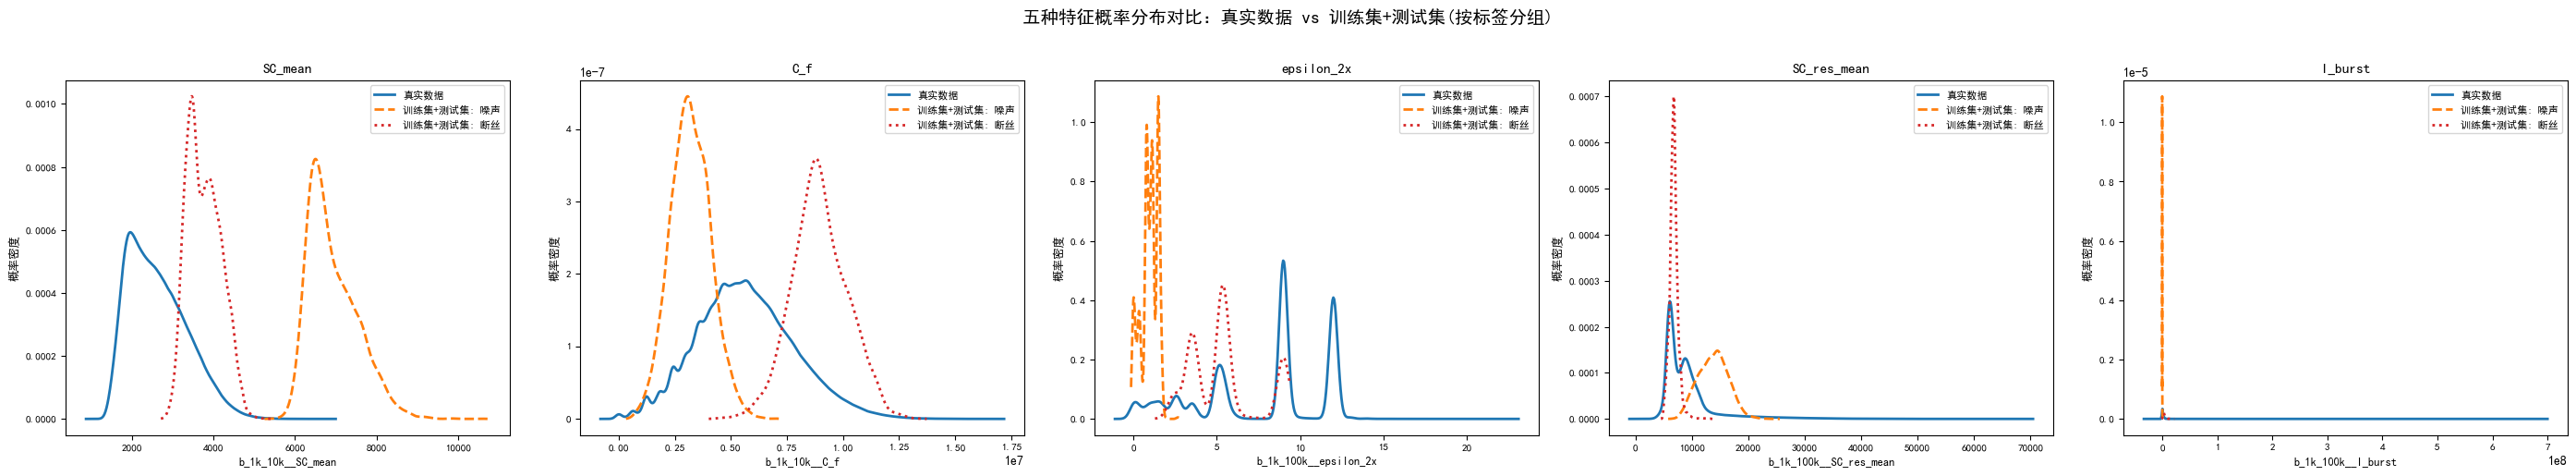

分布对比图已保存至 outputs/feature_distribution_comparison_A_vs_B.png


In [5]:
# =========================
# 13.3 绘制五种特征概率分布对比图
# =========================

fig, axes = plt.subplots(1, 5, figsize=(28, 5))

for idx, feat in enumerate(FEATURE_COLS):
    ax = axes[idx]

    # 真实数据：所有样本 KDE
    vals_A = df_A_all[feat].dropna().values
    if vals_A.size > 1:
        kde_A = gaussian_kde(vals_A)
        x_min = vals_A.min()
        x_max = vals_A.max()
        x_range = x_max - x_min
        if x_range < 1e-12:
            x_range = 1.0
        xs_A = np.linspace(x_min - 0.05 * x_range, x_max + 0.05 * x_range, 500)
        ax.plot(xs_A, kde_A(xs_A), color='#1f77b4', linewidth=2, label='真实数据')

    # 训练集+测试集-噪声
    vals_B0 = df_B_noise[feat].dropna().values
    if vals_B0.size > 1:
        kde_B0 = gaussian_kde(vals_B0)
        x_min0 = vals_B0.min()
        x_max0 = vals_B0.max()
        x_range0 = x_max0 - x_min0
        if x_range0 < 1e-12:
            x_range0 = 1.0
        xs_B0 = np.linspace(x_min0 - 0.05 * x_range0, x_max0 + 0.05 * x_range0, 500)
        ax.plot(xs_B0, kde_B0(xs_B0), color='#ff7f0e', linewidth=2, linestyle='--', label='训练集+测试集: 噪声')

    # 训练集+测试集-断丝
    vals_B1 = df_B_break[feat].dropna().values
    if vals_B1.size > 1:
        kde_B1 = gaussian_kde(vals_B1)
        x_min1 = vals_B1.min()
        x_max1 = vals_B1.max()
        x_range1 = x_max1 - x_min1
        if x_range1 < 1e-12:
            x_range1 = 1.0
        xs_B1 = np.linspace(x_min1 - 0.05 * x_range1, x_max1 + 0.05 * x_range1, 500)
        ax.plot(xs_B1, kde_B1(xs_B1), color='#d62728', linewidth=2, linestyle=':', label='训练集+测试集: 断丝')

    short_name = feat.split('__')[-1]
    ax.set_title(short_name, fontsize=11)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('概率密度', fontsize=9)
    ax.legend(fontsize=8, loc='best')
    ax.tick_params(labelsize=8)

fig.suptitle('五种特征概率分布对比：真实数据 vs 训练集+测试集(按标签分组)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(workspace / 'outputs' / 'feature_distribution_comparison_A_vs_B.png', dpi=150, bbox_inches='tight')
plt.show()
print('分布对比图已保存至 outputs/feature_distribution_comparison_A_vs_B.png')


In [6]:
# =========================
# 13.4 定量统计指标：均值、标准差、偏度、峰度、分位数、KS检验
# =========================

print('=' * 120)
print('五特征定量统计对比：真实数据 vs 训练集+测试集(按标签分组)')
print('=' * 120)

for feat in FEATURE_COLS:
    short_name = feat.split('__')[-1]
    print(f'\n--- {short_name} ({feat}) ---')

    v_real = df_A_all[feat].dropna().values
    v_noise = df_B_noise[feat].dropna().values
    v_break = df_B_break[feat].dropna().values

    for name, v in [('真实数据', v_real), ('训练集+测试集: 噪声', v_noise), ('训练集+测试集: 断丝', v_break)]:
        if v.size == 0:
            continue
        q25, q50, q75 = np.percentile(v, [25, 50, 75])
        print(f'  {name:20s}  n={v.size:<10d}  均值={np.mean(v):>14.4f}  '
              f'标准差={np.std(v):>10.4f}  偏度={skew(v):>10.4f}  '
              f'峰度={kurtosis(v):>10.4f}  P25={q25:>12.4f}  P50={q50:>12.4f}  P75={q75:>12.4f}')

    # KS检验：真实数据 vs 噪声、真实数据 vs 断丝
    if v_real.size > 0 and v_noise.size > 0:
        ks_real_noise, p_real_noise = kstest(
            np.random.choice(v_real, min(len(v_real), 10000), replace=False),
            np.random.choice(v_noise, min(len(v_noise), 10000), replace=False))
        print(f'  KS检验(真实 vs 噪声): statistic={ks_real_noise:.6f}, p={p_real_noise:.2e}')

    if v_real.size > 0 and v_break.size > 0:
        ks_real_break, p_real_break = kstest(
            np.random.choice(v_real, min(len(v_real), 10000), replace=False),
            np.random.choice(v_break, min(len(v_break), 10000), replace=False))
        print(f'  KS检验(真实 vs 断丝): statistic={ks_real_break:.6f}, p={p_real_break:.2e}')

    if v_noise.size > 0 and v_break.size > 0:
        ks_noise_break, p_noise_break = kstest(v_noise, v_break)
        print(f'  KS检验(噪声 vs 断丝): statistic={ks_noise_break:.6f}, p={p_noise_break:.2e}')

print('\n' + '=' * 120)


五特征定量统计对比：真实数据 vs 训练集+测试集(按标签分组)

--- SC_mean (b_1k_10k__SC_mean) ---
  真实数据                  n=719550      均值=     2641.0468  标准差=  716.5644  偏度=    0.6248  峰度=   -0.1201  P25=   2060.1279  P50=   2536.5783  P75=   3121.8376
  训练集+测试集: 噪声           n=5293        均值=     6924.1269  标准差=  606.3850  偏度=    0.8431  峰度=    0.5336  P25=   6459.1976  P50=   6782.6749  P75=   7319.3048
  训练集+测试集: 断丝           n=5293        均值=     3771.5451  标准差=  404.3620  偏度=    0.3455  峰度=   -0.6471  P25=   3449.1825  P50=   3738.2836  P75=   4073.2877
  KS检验(真实 vs 噪声): statistic=0.999900, p=0.00e+00
  KS检验(真实 vs 断丝): statistic=0.735894, p=0.00e+00
  KS检验(噪声 vs 断丝): statistic=1.000000, p=0.00e+00

--- C_f (b_1k_10k__C_f) ---
  真实数据                  n=719550      均值=  5670112.0240  标准差=2154944.2013  偏度=    0.2675  峰度=    0.0558  P25=4182600.3824  P50=5566157.7608  P75=7053875.6388
  训练集+测试集: 噪声           n=5293        均值=  3201331.6569  标准差=895049.8105  偏度=    0.1544  峰度=    0.0135  P25=2593165.3591  P50=31

### 13.5 分析：模型泛化能力验证

已在真实数据上验证了训练集训练的模型的泛化能力，
结果见 `2026-05-25-realdata_label_prediction_cross_condition.ipynb` 单元格 7。

**验证结论：模型泛化能力严重不足。**
- 真实数据中实际断丝信号仅有**几十例**。
- 模型在真实数据上预测出了**几十万个正样本**，假阳性率极高。
- 这表明训练集上学到的决策边界在真实数据上完全失效。

**根因分析**：结合上方定量统计结果，模型泛化失败的根本原因在于
**训练集与真实数据的特征分布差异过大**：
1. 训练集的"噪声"与真实数据的"噪声"（即真实数据整体）特征分布完全不同——
   所有 5 个特征的 KS 检验均显著（p<0.001），KS 统计量在 0.49~1.00 之间。
2. 模型在训练集上学到的"断丝"模式，可能在真实数据的大多数噪声窗口上
   也表现为高概率，导致大量假阳性。

**下一步方向**：
- 训练集代表性评估 + 数据增强/采样策略 → 缩小训练集与真实数据的分布差距
- 考虑域自适应（Domain Adaptation）、异常检测等替代方案
- 重点关注那几十条真实断丝信号的特征分布，验证训练集断丝样本的代表性


## 14. 训练集代表性评估：以真实数据为参考分布

利用真实数据（719,550条，本质为噪声分布）作为参考基准，评估训练集
（噪声 5,293 条 + 断丝 5,293 条）的特征分布是否覆盖了真实工况的范围。

评估指标：
- **MMD（Maximum Mean Discrepancy）**：量化两组分布的整体差异，值越小越接近
- **Wasserstein 距离**：分布之间的搬运距离（Earth Mover's Distance），值越小越接近
- **覆盖率**：训练集样本落在真实数据各分位数区间内的比例
- **OOD 比例**：训练集样本超出真实数据 P1~P99 范围的比例，值越小越好


### 14.1 导入模块与加载数据

In [3]:
# =========================
# 14.1 导入模块与加载数据
# =========================
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 导入 dist_comparison 模块（仅 metrics 计算函数）
src_dir = workspace / 'src'
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from dist_comparison.metrics import compute_mmd, compute_wasserstein, compute_coverage, compute_ood_ratio

# ============================================================
# 绘图函数（直接定义在 notebook 中，便于修改图属性）
# ============================================================

# 输出目录
OUTPUT_DIR = workspace / 'outputs' / 'training_set_representativeness'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def plot_coverage_comparison(coverages: dict, feature_names: list,
                             save_path: str = None) -> plt.Figure:
    """绘制训练集在各特征上对真实数据分位数的覆盖率对比。"""
    n_groups = len(coverages)
    n_feats = len(feature_names)
    quantiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    q_labels = ['P1', 'P5', 'P25', 'P50', 'P75', 'P95', 'P99']

    fig, axes = plt.subplots(1, n_feats, figsize=(5 * n_feats, 5), sharey=True)
    if n_feats == 1:
        axes = [axes]

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    group_names = list(coverages.keys())

    for f_idx, feat in enumerate(feature_names):
        ax = axes[f_idx]
        x = np.arange(len(quantiles))
        width = 0.8 / n_groups

        for g_idx, g_name in enumerate(group_names):
            cov_lower = [coverages[g_name][feat][q]['coverage_lower'] for q in quantiles]
            cov_upper = [coverages[g_name][feat][q]['coverage_upper'] for q in quantiles]
            ax.bar(x + g_idx * width, cov_lower, width, label=f'{g_name} (下尾)',
                   color=colors[g_idx], alpha=0.7)

        ax.set_xticks(x + width * (n_groups - 1) / 2)
        ax.set_xticklabels(q_labels, fontsize=10)
        ax.set_title(feat, fontsize=12)
        ax.set_ylabel('覆盖率', fontsize=10)
        ax.set_ylim(0, 1.05)
        ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    fig.suptitle('训练集对真实数据各分位数的覆盖率对比', fontsize=14, y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    return fig


def plot_distribution_overlap(x_ref: np.ndarray, x_test_noise: np.ndarray,
                              x_test_break: np.ndarray,
                              feature_names: list,
                              save_path: str = None) -> plt.Figure:
    """绘制真实数据与训练集（噪声/断丝）的分布重叠区域。"""
    n_feats = len(feature_names)
    fig, axes = plt.subplots(1, n_feats, figsize=(5 * n_feats, 4.5))
    if n_feats == 1:
        axes = [axes]

    for idx, feat in enumerate(feature_names):
        ax = axes[idx]

        v_ref = x_ref[:, idx]
        v_noise = x_test_noise[:, idx]
        v_break = x_test_break[:, idx]

        x_min = min(v_ref.min(), v_noise.min(), v_break.min())
        x_max = max(v_ref.max(), v_noise.max(), v_break.max())
        x_range = max(x_max - x_min, 1e-10)
        xs = np.linspace(x_min - 0.02 * x_range, x_max + 0.02 * x_range, 500)

        for v, color, label, ls in [
            (v_ref, '#1f77b4', '真实数据(噪声参考)', '-'),
            (v_noise, '#ff7f0e', '训练集: 噪声', '--'),
            (v_break, '#d62728', '训练集: 断丝', ':'),
        ]:
            if v.size > 1:
                kde = gaussian_kde(v)
                ys = kde(xs)
                ax.plot(xs, ys, color=color, linewidth=2, linestyle=ls, label=label)
                ax.fill_between(xs, 0, ys, color=color, alpha=0.15)

        ax.set_title(feat, fontsize=11)
        ax.set_xlabel('特征值', fontsize=9)
        ax.set_ylabel('概率密度', fontsize=9)
        ax.legend(fontsize=7, loc='best')
        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.2)

    fig.suptitle('真实数据与训练集特征分布重叠对比', fontsize=13, y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    return fig


def plot_ood_detection(ood_results: dict, feature_names: list,
                       save_path: str = None) -> plt.Figure:
    """绘制 OOD 检测结果：训练集超出真实数据范围的样本比例。"""
    n_groups = len(ood_results)
    n_feats = len(feature_names)
    group_names = list(ood_results.keys())

    fig, axes = plt.subplots(1, n_feats, figsize=(5 * n_feats, 5), sharey=True)
    if n_feats == 1:
        axes = [axes]

    colors = ['#ff7f0e', '#2ca02c']

    for f_idx, feat in enumerate(feature_names):
        ax = axes[f_idx]
        x = np.arange(n_groups)
        width = 0.35

        for g_idx, g_name in enumerate(group_names):
            ood = ood_results[g_name][feat]
            below = ood['ood_below_pct'] * 100
            above = ood['ood_above_pct'] * 100
            ax.bar(x[g_idx] - width / 2, below, width, label=f'{g_name}: 低于P1',
                   color=colors[g_idx], alpha=0.7)
            ax.bar(x[g_idx] + width / 2, above, width, label=f'{g_name}: 高于P99',
                   color=colors[g_idx], alpha=0.3)

        ax.set_xticks(x)
        ax.set_xticklabels([g.replace('训练集+测试集: ', '') for g in group_names], fontsize=10)
        ax.set_title(feat, fontsize=11)
        ax.set_ylabel('OOD 样本比例 (%)', fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(axis='y', alpha=0.3)

    fig.suptitle('训练集 OOD 样本比例（超出真实数据 P1~P99 范围）', fontsize=13, y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    return fig


def plot_representativeness_summary(mmd_results: dict, wass_results: dict,
                                    coverage_results: dict, ood_results: dict,
                                    feature_names: list,
                                    save_path: str = None) -> plt.Figure:
    """绘制训练集代表性综合评估图。"""
    n_feats = len(feature_names)
    group_names = list(mmd_results.keys())
    n_groups = len(group_names)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. MMD 对比
    ax = axes[0, 0]
    x = np.arange(n_feats)
    width = 0.8 / n_groups
    colors = ['#ff7f0e', '#2ca02c']
    for g_idx, g_name in enumerate(group_names):
        vals = [mmd_results[g_name][f] for f in feature_names]
        ax.bar(x + g_idx * width, vals, width, label=g_name.replace('训练集+测试集: ', ''),
               color=colors[g_idx], alpha=0.8)
    ax.set_xticks(x + width * (n_groups - 1) / 2)
    ax.set_xticklabels(feature_names, fontsize=9, rotation=45, ha='right')
    ax.set_ylabel('MMD²', fontsize=10)
    ax.set_title('MMD 距离（越小表示分布越接近真实数据）', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # 2. Wasserstein 距离对比
    ax = axes[0, 1]
    for g_idx, g_name in enumerate(group_names):
        vals = [wass_results[g_name][f] for f in feature_names]
        ax.bar(x + g_idx * width, vals, width, label=g_name.replace('训练集+测试集: ', ''),
               color=colors[g_idx], alpha=0.8)
    ax.set_xticks(x + width * (n_groups - 1) / 2)
    ax.set_xticklabels(feature_names, fontsize=9, rotation=45, ha='right')
    ax.set_ylabel('Wasserstein 距离', fontsize=10)
    ax.set_title('Wasserstein 距离（越小表示分布越接近真实数据）', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # 3. 整体覆盖率对比
    ax = axes[1, 0]
    for g_idx, g_name in enumerate(group_names):
        vals = [coverage_results[g_name][f]['overall']['coverage_main'] * 100 for f in feature_names]
        ax.bar(x + g_idx * width, vals, width, label=g_name.replace('训练集+测试集: ', ''),
               color=colors[g_idx], alpha=0.8)
    ax.axhline(y=95, color='red', linestyle='--', alpha=0.5, label='95% 基准线')
    ax.set_xticks(x + width * (n_groups - 1) / 2)
    ax.set_xticklabels(feature_names, fontsize=9, rotation=45, ha='right')
    ax.set_ylabel('覆盖率 (%)', fontsize=10)
    ax.set_title('训练集落在真实数据 P2.5~P97.5 范围内的比例', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # 4. OOD 比例对比
    ax = axes[1, 1]
    for g_idx, g_name in enumerate(group_names):
        vals = [ood_results[g_name][f]['ood_total_pct'] * 100 for f in feature_names]
        ax.bar(x + g_idx * width, vals, width, label=g_name.replace('训练集+测试集: ', ''),
               color=colors[g_idx], alpha=0.8)
    ax.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='5% 警戒线')
    ax.set_xticks(x + width * (n_groups - 1) / 2)
    ax.set_xticklabels(feature_names, fontsize=9, rotation=45, ha='right')
    ax.set_ylabel('OOD 比例 (%)', fontsize=10)
    ax.set_title('训练集超出真实数据 P1~P99 范围的样本比例', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    fig.suptitle('训练集代表性综合评估（以真实数据为参考分布）', fontsize=14, y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    return fig


# ============================================================
# 加载数据
# ============================================================
FEATURE_COLS = [
    'b_1k_10k__SC_mean',
    'b_1k_10k__C_f',
    'b_1k_100k__epsilon_2x',
    'b_1k_100k__SC_res_mean',
    'b_1k_100k__I_burst',
]
SHORT_NAMES = [c.split('__')[-1] for c in FEATURE_COLS]

# 真实数据（参考分布）
dir_A_v3 = workspace / 'outputs' / 'realdata_feature_dataset_20260519_v3'
dir_A_0523 = workspace / 'outputs' / 'realdata_feature_dataset_20260523'
dfs_A = []
for d in [dir_A_v3, dir_A_0523]:
    for fp in sorted(glob.glob(str(d / '*_features_*_part_*.csv'))):
        dfs_A.append(pd.read_csv(fp, usecols=FEATURE_COLS, encoding='utf-8'))
df_real = pd.concat(dfs_A, ignore_index=True)
print(f'真实数据（参考分布）: {len(df_real)} 条')

# 训练集+测试集
dir_B = workspace / 'outputs' / 'dataset_build_260518_features_gpu'
cols_B = FEATURE_COLS + ['label']
dfs_B = []
for fp in sorted(glob.glob(str(dir_B / '*_features.csv'))):
    dfs_B.append(pd.read_csv(fp, usecols=cols_B, encoding='utf-8'))
df_B_all = pd.concat(dfs_B, ignore_index=True)
df_noise = df_B_all[df_B_all['label'] == 0].reset_index(drop=True)
df_break = df_B_all[df_B_all['label'] == 1].reset_index(drop=True)
print(f'训练集+测试集 噪声: {len(df_noise)} 条')
print(f'训练集+测试集 断丝: {len(df_break)} 条')


真实数据（参考分布）: 719550 条
训练集+测试集 噪声: 5293 条
训练集+测试集 断丝: 5293 条


### 14.2 计算各评估指标

In [4]:
# =========================
# 14.2 计算各评估指标
# =========================
print('=' * 100)
print('训练集代表性评估：以真实数据为参考分布')
print('=' * 100)

groups = {
    '训练集+测试集: 噪声': df_noise,
    '训练集+测试集: 断丝': df_break,
}

mmd_results = {}
wass_results = {}
coverage_results = {}
ood_results = {}

for g_name, df_g in groups.items():
    mmd_results[g_name] = {}
    wass_results[g_name] = {}
    coverage_results[g_name] = {}
    ood_results[g_name] = {}

    for feat, short in zip(FEATURE_COLS, SHORT_NAMES):
        v_ref = df_real[feat].dropna().values
        v_g = df_g[feat].dropna().values

        mmd_val = compute_mmd(v_ref, v_g)
        wass_val = compute_wasserstein(v_ref, v_g)
        cov_val = compute_coverage(v_ref, v_g)
        ood_val = compute_ood_ratio(v_ref, v_g)

        mmd_results[g_name][short] = mmd_val
        wass_results[g_name][short] = wass_val
        coverage_results[g_name][short] = cov_val
        ood_results[g_name][short] = ood_val

        print(f'{g_name} - {short}:')
        print(f'  MMD² = {mmd_val:.8f}')
        print(f'  Wasserstein = {wass_val:.4f}')
        print(f'  覆盖率(P2.5~P97.5) = {cov_val["overall"]["coverage_main"]*100:.2f}%')
        print(f'  OOD比例 = {ood_val["ood_total_pct"]*100:.2f}% (低于P1: {ood_val["ood_below_pct"]*100:.2f}%, 高于P99: {ood_val["ood_above_pct"]*100:.2f}%)')
        print()


训练集代表性评估：以真实数据为参考分布
训练集+测试集: 噪声 - SC_mean:
  MMD² = 0.00753680
  Wasserstein = 4283.0801
  覆盖率(P2.5~P97.5) = 0.00%
  OOD比例 = 100.00% (低于P1: 0.00%, 高于P99: 100.00%)

训练集+测试集: 噪声 - C_f:
  MMD² = 0.00429527
  Wasserstein = 2477580.1109
  覆盖率(P2.5~P97.5) = 95.48%
  OOD比例 = 1.04% (低于P1: 1.04%, 高于P99: 0.00%)

训练集+测试集: 噪声 - epsilon_2x:
  MMD² = 0.29580136
  Wasserstein = 6.6707
  覆盖率(P2.5~P97.5) = 90.80%
  OOD比例 = 0.00% (低于P1: 0.00%, 高于P99: 0.00%)

训练集+测试集: 噪声 - SC_res_mean:
  MMD² = 0.00635192
  Wasserstein = 5364.2824
  覆盖率(P2.5~P97.5) = 99.98%
  OOD比例 = 0.00% (低于P1: 0.00%, 高于P99: 0.00%)

训练集+测试集: 噪声 - I_burst:
  MMD² = 0.03665969
  Wasserstein = 2464925.5103
  覆盖率(P2.5~P97.5) = 84.56%
  OOD比例 = 8.46% (低于P1: 8.46%, 高于P99: 0.00%)

训练集+测试集: 断丝 - SC_mean:
  MMD² = 0.00489562
  Wasserstein = 1131.3125
  覆盖率(P2.5~P97.5) = 83.90%
  OOD比例 = 3.68% (低于P1: 0.00%, 高于P99: 3.68%)

训练集+测试集: 断丝 - C_f:
  MMD² = 0.00485908
  Wasserstein = 3289536.0838
  覆盖率(P2.5~P97.5) = 83.02%
  OOD比例 = 4.95% (低于P1: 0.00%, 

### 14.3 绘制覆盖率对比图

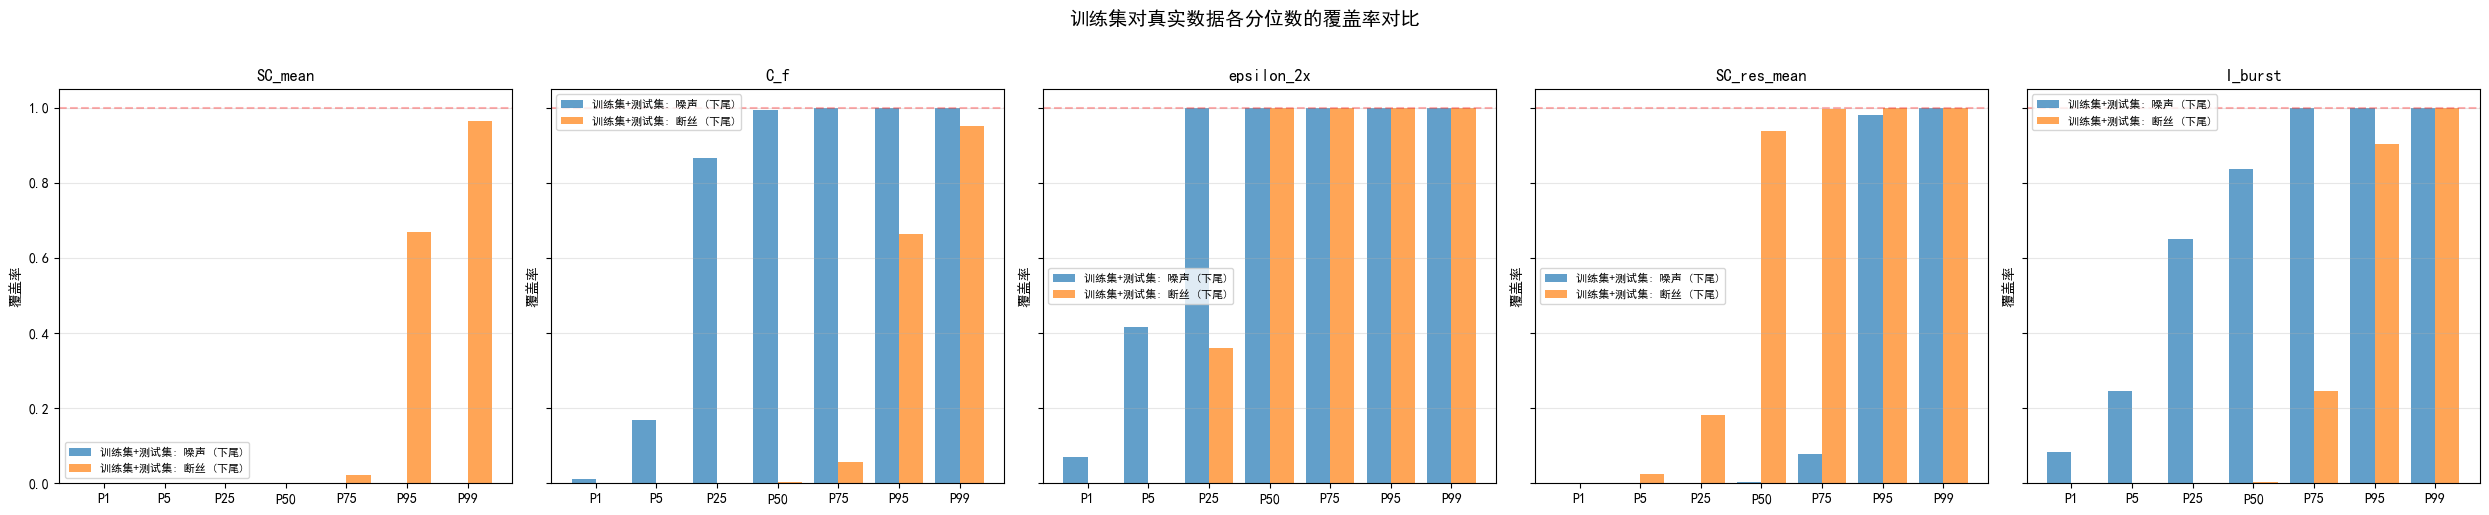

覆盖率对比图已保存至 outputs/training_set_representativeness/training_set_coverage_comparison.png


In [5]:
# =========================
# 14.3 绘制覆盖率对比图
# =========================
fig = plot_coverage_comparison(
    coverage_results, SHORT_NAMES,
    save_path=str(OUTPUT_DIR / 'training_set_coverage_comparison.png'))
plt.show()
print('覆盖率对比图已保存至 outputs/training_set_representativeness/training_set_coverage_comparison.png')


### 14.4 绘制分布重叠对比图

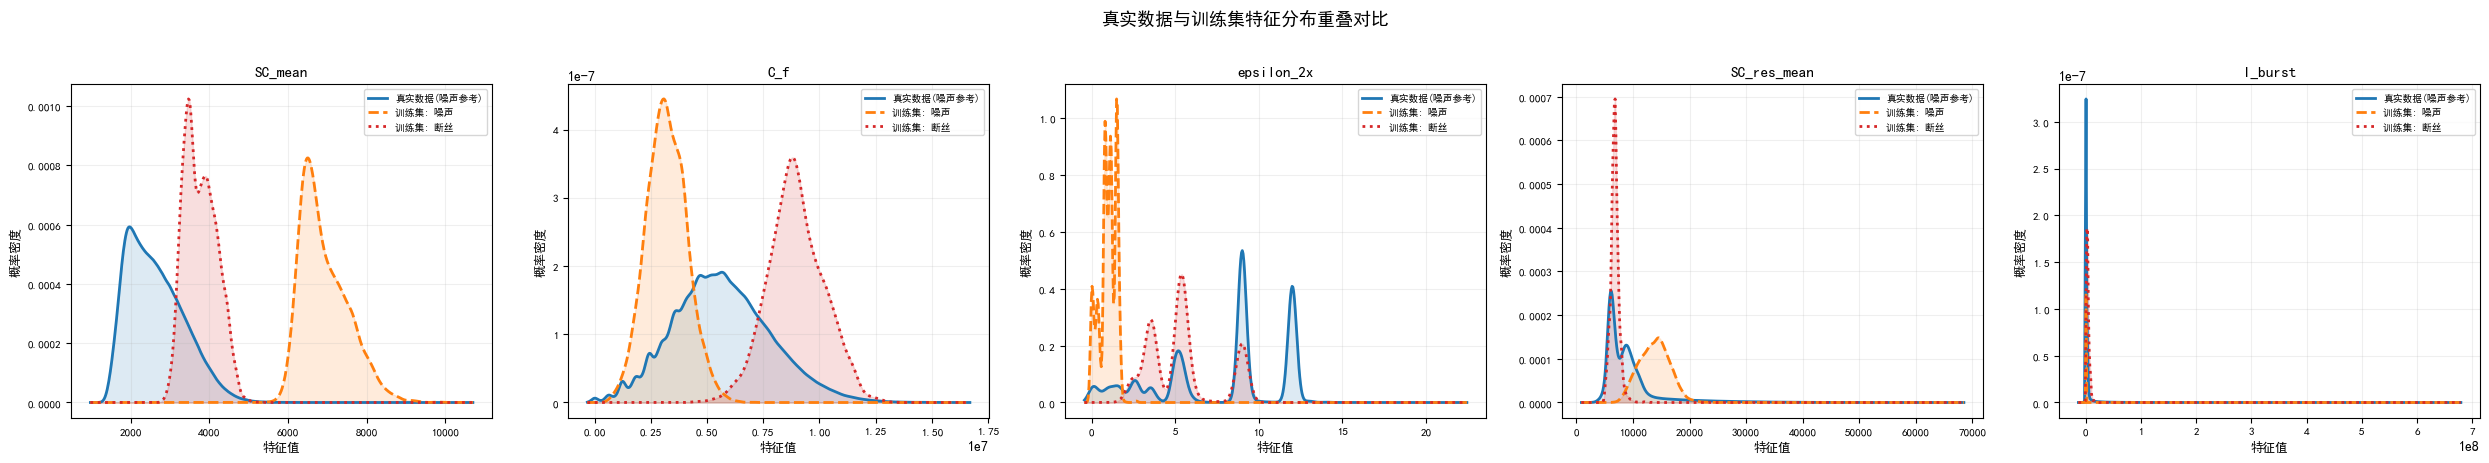

分布重叠对比图已保存至 outputs/training_set_representativeness/distribution_overlap_comparison.png


In [6]:
# =========================
# 14.4 绘制分布重叠对比图
# =========================
x_ref = df_real[FEATURE_COLS].dropna().values
x_noise = df_noise[FEATURE_COLS].dropna().values
x_break = df_break[FEATURE_COLS].dropna().values

fig = plot_distribution_overlap(
    x_ref, x_noise, x_break, SHORT_NAMES,
    save_path=str(OUTPUT_DIR / 'distribution_overlap_comparison.png'))
plt.show()
print('分布重叠对比图已保存至 outputs/training_set_representativeness/distribution_overlap_comparison.png')


### 14.5 绘制 OOD 检测结果图

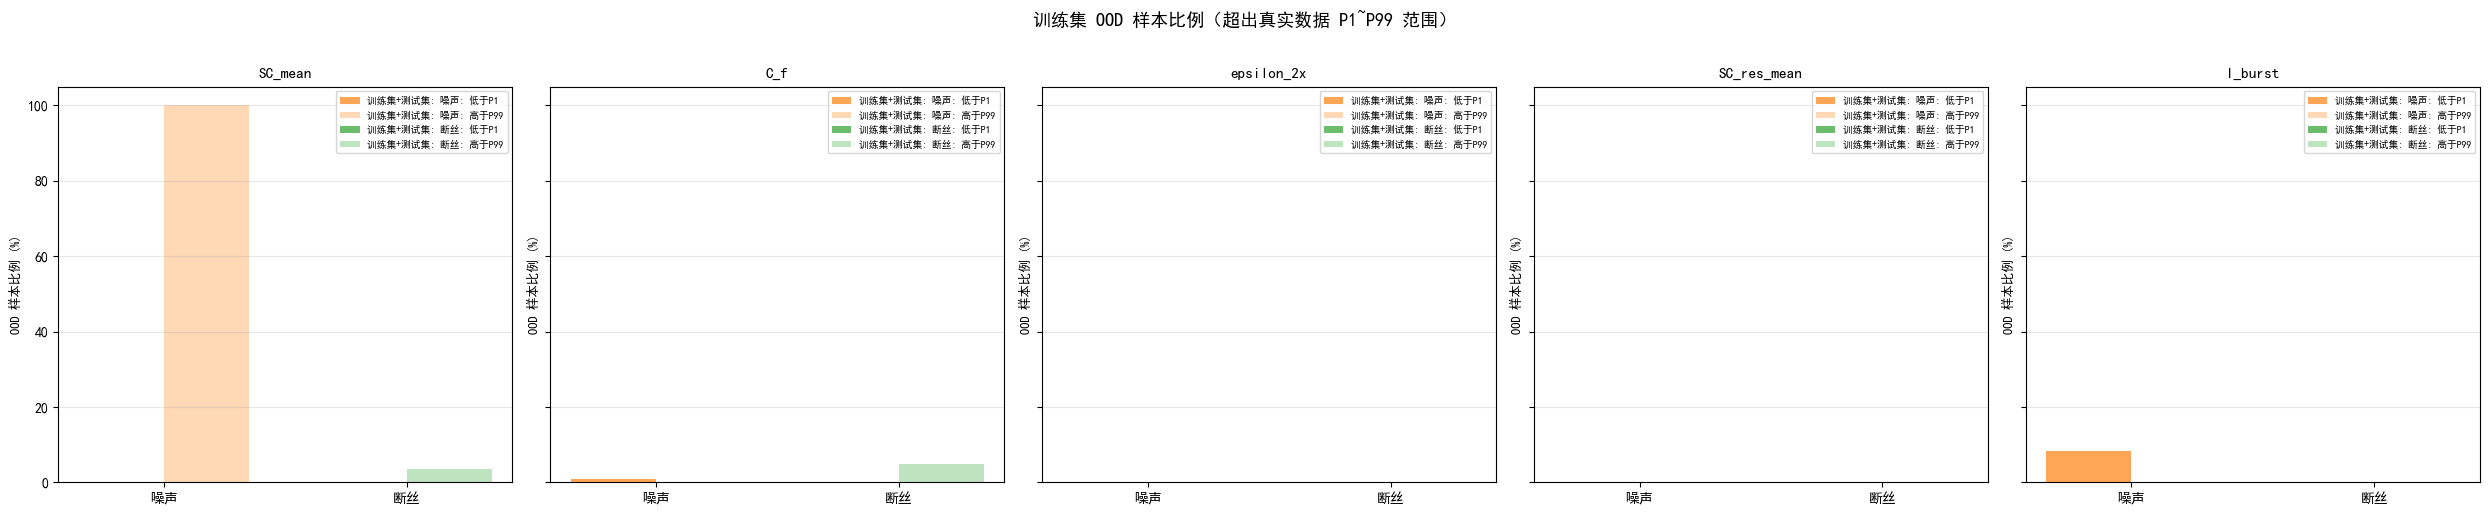

OOD 检测结果图已保存至 outputs/training_set_representativeness/ood_detection_results.png


In [7]:
# =========================
# 14.5 绘制 OOD 检测结果图
# =========================
fig = plot_ood_detection(
    ood_results, SHORT_NAMES,
    save_path=str(OUTPUT_DIR / 'ood_detection_results.png'))
plt.show()
print('OOD 检测结果图已保存至 outputs/training_set_representativeness/ood_detection_results.png')


### 14.6 训练集代表性综合评估图

C:\Users\QiGh\AppData\Local\Temp\ipykernel_25836\3422828055.py:236: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\QiGh\AppData\Local\Temp\ipykernel_25836\3422828055.py:239: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\QiGh\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


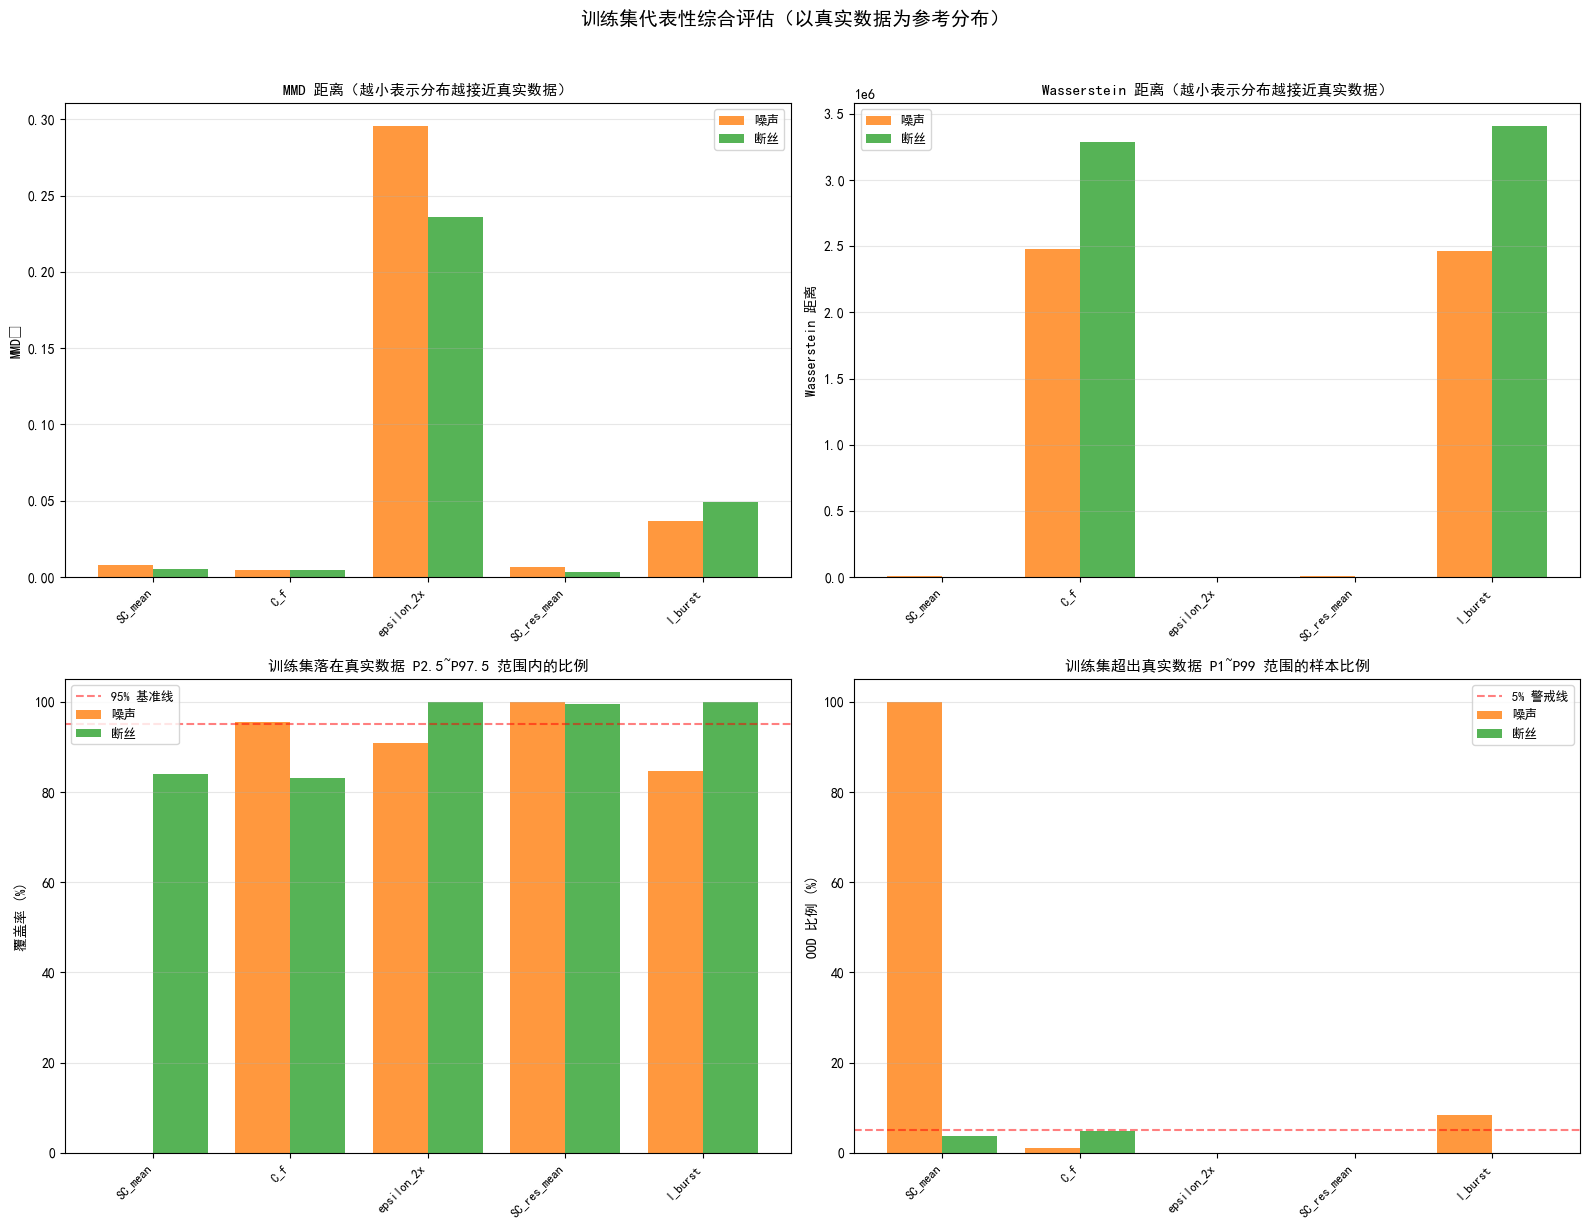

综合评估图已保存至 outputs/training_set_representativeness/representativeness_summary.png


In [8]:
# =========================
# 14.6 训练集代表性综合评估图
# =========================
fig = plot_representativeness_summary(
    mmd_results, wass_results, coverage_results, ood_results, SHORT_NAMES,
    save_path=str(OUTPUT_DIR / 'representativeness_summary.png'))
plt.show()
print('综合评估图已保存至 outputs/training_set_representativeness/representativeness_summary.png')


### 14.7 评估结果解读

基于以上四张评估图，对训练集代表性进行综合解读：

1. **MMD 与 Wasserstein 距离**：值越大表示训练集分布与真实数据分布差异越大。
   如果训练集噪声的 MMD/Wasserstein 显著大于训练集断丝，说明噪声分布偏移更严重。

2. **覆盖率**：理想情况下训练集样本应覆盖真实数据的大部分特征范围（>90%）。
   如果覆盖率偏低，说明训练集未能覆盖真实工况的某些特征区域。

3. **OOD 比例**：训练集中超出真实数据 P1~P99 范围的样本比例。
   OOD 比例高说明训练集包含了大量真实数据中不存在的极端特征值，
   或者训练集分布整体偏移导致大部分样本落在真实数据范围之外。

4. **分布重叠**：直观展示训练集（噪声/断丝）与真实数据的分布重叠区域。
   重叠越少，说明训练集对真实数据的代表性越差。
